In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import joblib

# LOAD DATA

In [2]:

circuits = pd.read_csv('dataset/circuits.csv')  #
constructors = pd.read_csv('dataset/constructors.csv') #
constructor_results = pd.read_csv('dataset/constructor_results.csv')
constructor_standings = pd.read_csv('dataset/constructor_standings.csv')
drivers = pd.read_csv('dataset/drivers.csv') #
driver_standings = pd.read_csv('dataset/driver_standings.csv')
lap_times = pd.read_csv('dataset/lap_times.csv') #
pit_stops = pd.read_csv('dataset/pit_stops.csv')  # 
qualifying = pd.read_csv('dataset/qualifying.csv') 
races = pd.read_csv('dataset/races.csv')  #
results = pd.read_csv('dataset/results.csv') #
seasons = pd.read_csv('dataset/seasons.csv')
sprint_results = pd.read_csv('dataset/sprint_results.csv')
status = pd.read_csv('dataset/status.csv')

# CREATE DF

In [3]:
lap_times.rename(columns={
    'time': 'lap_time',
    'milliseconds': 'lap_time_ms'
}, inplace=True)
lap_times.drop(columns=['lap_time'], inplace=True)
lap_times

,raceId,driverId,lap,position,lap_time_ms
0,841,20,1,1,98109
1,841,20,2,1,93006
2,841,20,3,1,92713
3,841,20,4,1,92803
4,841,20,5,1,92342
...,...,...,...,...,...
618761,1171,864,53,13,95123
618762,1171,866,53,14,94314
618763,1171,832,53,15,94539
618764,1171,861,53,16,94685


In [4]:
df = lap_times.copy()

In [5]:
df

,raceId,driverId,lap,position,lap_time_ms
0,841,20,1,1,98109
1,841,20,2,1,93006
2,841,20,3,1,92713
3,841,20,4,1,92803
4,841,20,5,1,92342
...,...,...,...,...,...
618761,1171,864,53,13,95123
618762,1171,866,53,14,94314
618763,1171,832,53,15,94539
618764,1171,861,53,16,94685


In [6]:
races = races.drop(columns=['fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
       'quali_date', 'quali_time', 'sprint_date', 'sprint_time', 'url'])

In [7]:
races.rename(columns={
    'name': 'race_name',
    'date': 'race_date',
    'time': 'race_time',
    'year': 'race_year'
}, inplace=True)
races = races[races['race_year'] >= 2010]

In [8]:
races.info()

<class 'pandas.DataFrame'>
Index: 351 entries, 336 to 1170
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   raceId     351 non-null    int64
 1   race_year  351 non-null    int64
 2   round      351 non-null    int64
 3   circuitId  351 non-null    int64
 4   race_name  351 non-null    str  
 5   race_date  351 non-null    str  
 6   race_time  351 non-null    str  
dtypes: int64(4), str(3)
memory usage: 21.9 KB


In [9]:
df = df.merge(races, on='raceId', how='inner')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 372493 entries, 0 to 372492
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   raceId       372493 non-null  int64
 1   driverId     372493 non-null  int64
 2   lap          372493 non-null  int64
 3   position     372493 non-null  int64
 4   lap_time_ms  372493 non-null  int64
 5   race_year    372493 non-null  int64
 6   round        372493 non-null  int64
 7   circuitId    372493 non-null  int64
 8   race_name    372493 non-null  str  
 9   race_date    372493 non-null  str  
 10  race_time    372493 non-null  str  
dtypes: int64(8), str(3)
memory usage: 31.3 MB


In [11]:
pit_stops_renamed = pit_stops.rename(columns={'lap': 'pit_lap'})
df = df.merge(
    pit_stops_renamed[['raceId', 'driverId', 'pit_lap']],
    left_on=['raceId', 'driverId', 'lap'],
    right_on=['raceId', 'driverId', 'pit_lap'],
    how='left'
)


In [12]:
df

,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,race_name,race_date,race_time,pit_lap
0,841,20,1,1,98109,2011,1,1,Australian Grand Prix,2011-03-27,06:00:00,NaN
1,841,20,2,1,93006,2011,1,1,Australian Grand Prix,2011-03-27,06:00:00,NaN
2,841,20,3,1,92713,2011,1,1,Australian Grand Prix,2011-03-27,06:00:00,NaN
3,841,20,4,1,92803,2011,1,1,Australian Grand Prix,2011-03-27,06:00:00,NaN
4,841,20,5,1,92342,2011,1,1,Australian Grand Prix,2011-03-27,06:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
372488,1171,864,53,13,95123,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,NaN
372489,1171,866,53,14,94314,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,NaN
372490,1171,832,53,15,94539,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,NaN
372491,1171,861,53,16,94685,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 372493 entries, 0 to 372492
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   raceId       372493 non-null  int64  
 1   driverId     372493 non-null  int64  
 2   lap          372493 non-null  int64  
 3   position     372493 non-null  int64  
 4   lap_time_ms  372493 non-null  int64  
 5   race_year    372493 non-null  int64  
 6   round        372493 non-null  int64  
 7   circuitId    372493 non-null  int64  
 8   race_name    372493 non-null  str    
 9   race_date    372493 non-null  str    
 10  race_time    372493 non-null  str    
 11  pit_lap      12863 non-null   float64
dtypes: float64(1), int64(8), str(3)
memory usage: 34.1 MB


In [14]:
df['pit_stop'] = df['pit_lap'].notna().astype(int)
df.drop(columns=['pit_lap'], inplace=True)

In [15]:
df['tyre_age'] = 0
df = df.sort_values(['raceId', 'driverId', 'lap'])
for (race, driver), group in df.groupby(['raceId', 'driverId']):
    last_pit = 0
    ages = []
    
    for lap, pit in zip(group['lap'], group['pit_stop']):
        if pit == 1:
            last_pit = lap
        ages.append(lap - last_pit)
    
    df.loc[group.index, 'tyre_age'] = ages

In [16]:
df

,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,race_name,race_date,race_time,pit_stop,tyre_age
113843,337,1,1,5,128558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,1
113844,337,1,2,5,123578,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,2
113845,337,1,3,5,123722,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,3
113846,337,1,4,5,123558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,4
113847,337,1,5,5,123283,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372410,1171,866,49,14,95229,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,31
372430,1171,866,50,14,94845,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,32
372450,1171,866,51,14,94600,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,33
372470,1171,866,52,14,94585,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,34


In [17]:
df = df.merge(
    results[['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder']],
    on=['raceId', 'driverId'],
    how='left'
)

In [18]:
df

,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,race_name,race_date,race_time,pit_stop,tyre_age,constructorId,grid,positionOrder
0,337,1,1,5,128558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,1,1,4,3
1,337,1,2,5,123578,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,2,1,4,3
2,337,1,3,5,123722,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,3,1,4,3
3,337,1,4,5,123558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,4,1,4,3
4,337,1,5,5,123283,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,5,1,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372488,1171,866,49,14,95229,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,31,215,10,14
372489,1171,866,50,14,94845,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,32,215,10,14
372490,1171,866,51,14,94600,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,33,215,10,14
372491,1171,866,52,14,94585,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,34,215,10,14


In [19]:

df = df.merge(
    circuits[['circuitId', 'lat', 'lng', 'alt']],
    on='circuitId',
    how='left'
)
df

,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,race_name,race_date,race_time,pit_stop,tyre_age,constructorId,grid,positionOrder,lat,lng,alt
0,337,1,1,5,128558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,1,1,4,3,26.0325,50.5106,7
1,337,1,2,5,123578,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,2,1,4,3,26.0325,50.5106,7
2,337,1,3,5,123722,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,3,1,4,3,26.0325,50.5106,7
3,337,1,4,5,123558,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,4,1,4,3,26.0325,50.5106,7
4,337,1,5,5,123283,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,5,1,4,3,26.0325,50.5106,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372488,1171,866,49,14,95229,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,31,215,10,14,34.8431,136.5410,45
372489,1171,866,50,14,94845,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,32,215,10,14,34.8431,136.5410,45
372490,1171,866,51,14,94600,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,33,215,10,14,34.8431,136.5410,45
372491,1171,866,52,14,94585,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,34,215,10,14,34.8431,136.5410,45


In [20]:
df.to_csv("f1.csv")

# EDA

In [21]:
df.isnull().sum()

raceId           0
driverId         0
lap              0
position         0
lap_time_ms      0
race_year        0
round            0
circuitId        0
race_name        0
race_date        0
race_time        0
pit_stop         0
tyre_age         0
constructorId    0
grid             0
positionOrder    0
lat              0
lng              0
alt              0
dtype: int64

In [22]:
df.isna().sum()

raceId           0
driverId         0
lap              0
position         0
lap_time_ms      0
race_year        0
round            0
circuitId        0
race_name        0
race_date        0
race_time        0
pit_stop         0
tyre_age         0
constructorId    0
grid             0
positionOrder    0
lat              0
lng              0
alt              0
dtype: int64

In [23]:
df.describe()
df['lap_time_ms'].median()

np.float64(93507.0)

In [24]:
df.columns

Index(['raceId', 'driverId', 'lap', 'position', 'lap_time_ms', 'race_year',
       'round', 'circuitId', 'race_name', 'race_date', 'race_time', 'pit_stop',
       'tyre_age', 'constructorId', 'grid', 'positionOrder', 'lat', 'lng',
       'alt'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 372493 entries, 0 to 372492
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   raceId         372493 non-null  int64  
 1   driverId       372493 non-null  int64  
 2   lap            372493 non-null  int64  
 3   position       372493 non-null  int64  
 4   lap_time_ms    372493 non-null  int64  
 5   race_year      372493 non-null  int64  
 6   round          372493 non-null  int64  
 7   circuitId      372493 non-null  int64  
 8   race_name      372493 non-null  str    
 9   race_date      372493 non-null  str    
 10  race_time      372493 non-null  str    
 11  pit_stop       372493 non-null  int64  
 12  tyre_age       372493 non-null  int64  
 13  constructorId  372493 non-null  int64  
 14  grid           372493 non-null  str    
 15  positionOrder  372493 non-null  int64  
 16  lat            372493 non-null  float64
 17  lng            372493 non-null  float64


In [26]:
numerical_cols = [
    'lap', 'lap_time_ms', 'race_year', 'circuitId', 'pit_stop', 'tyre_age', 
]

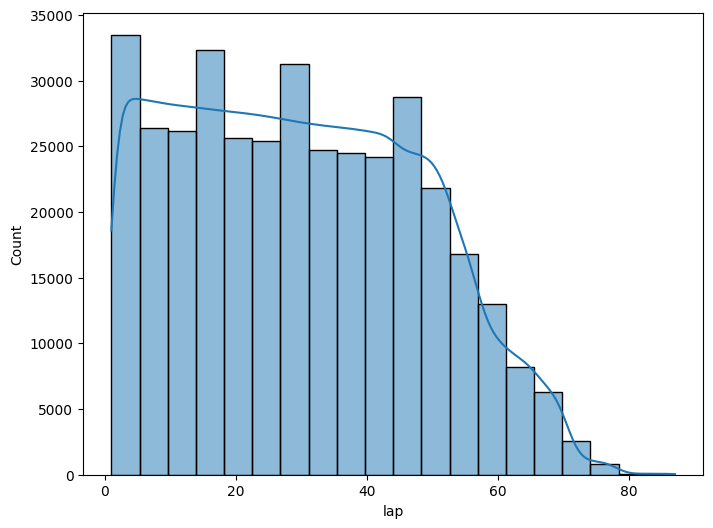

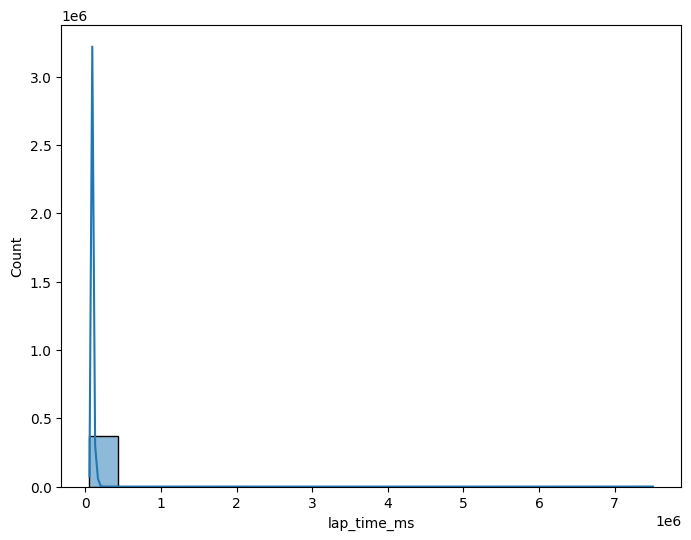

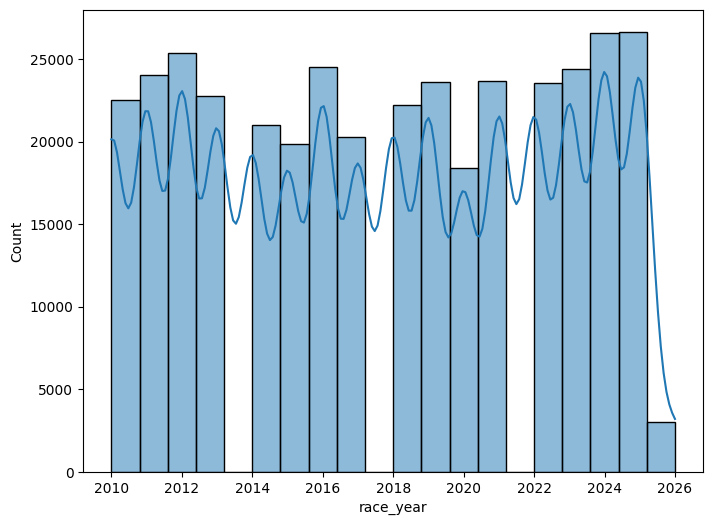

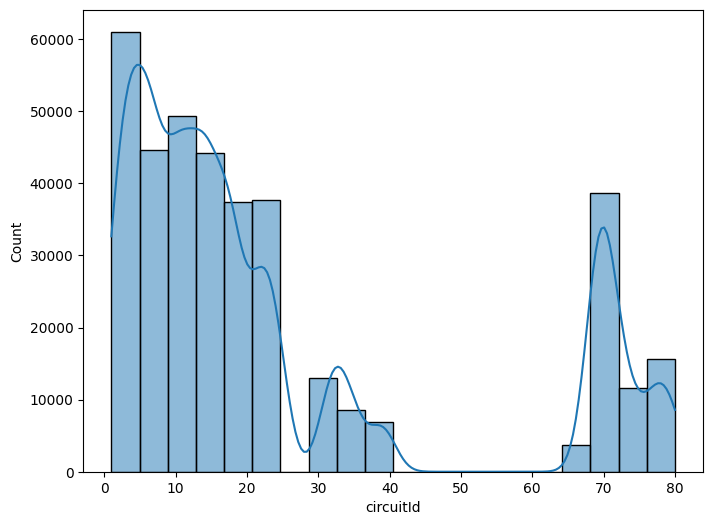

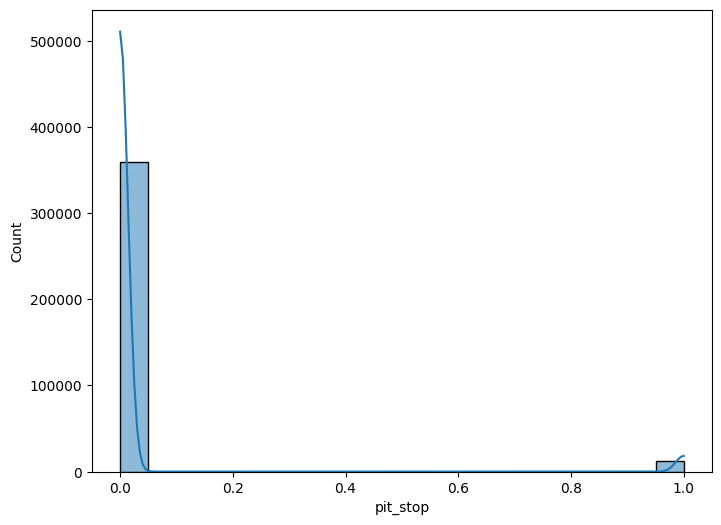

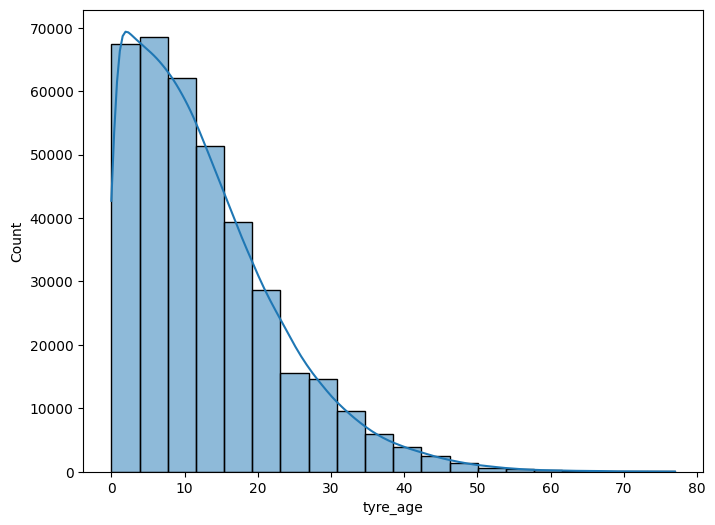

In [27]:
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=20)

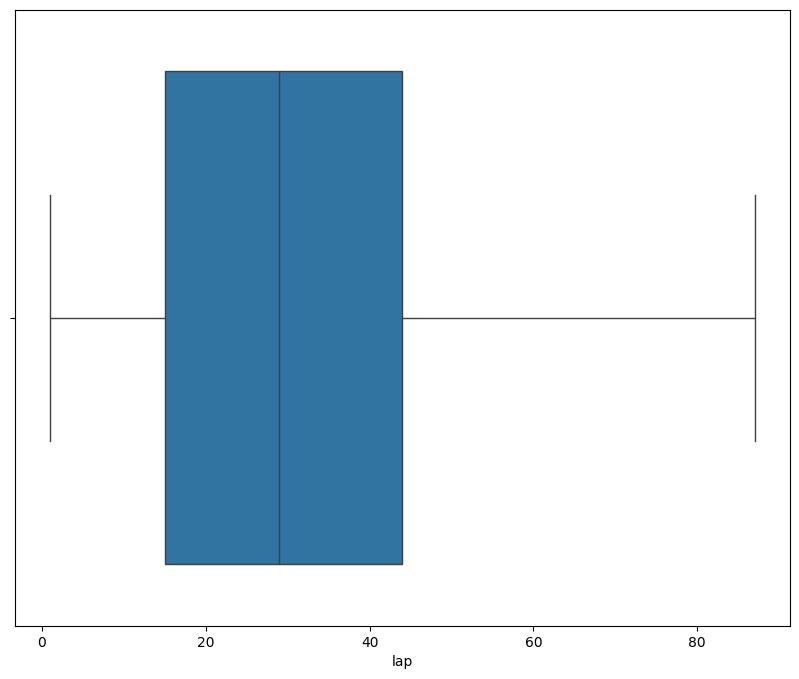

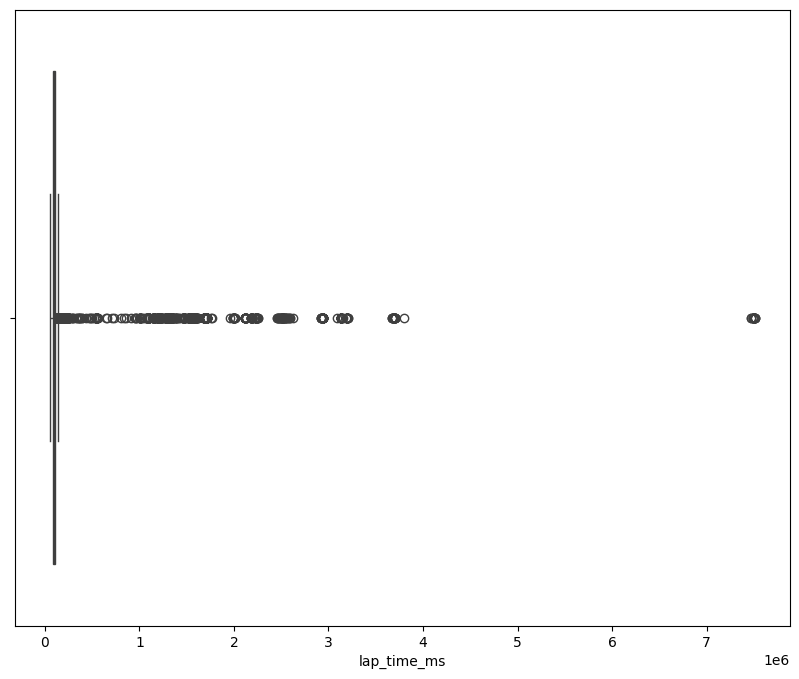

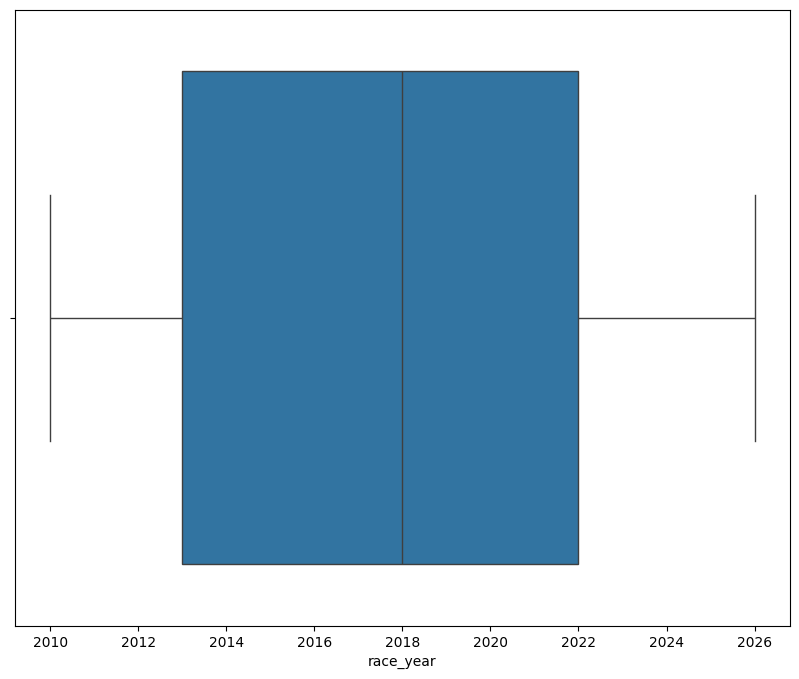

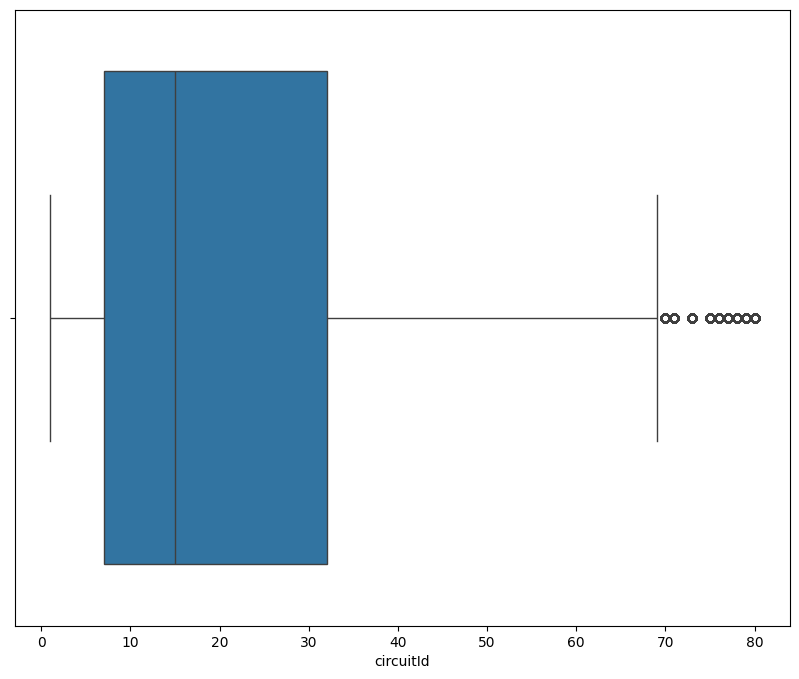

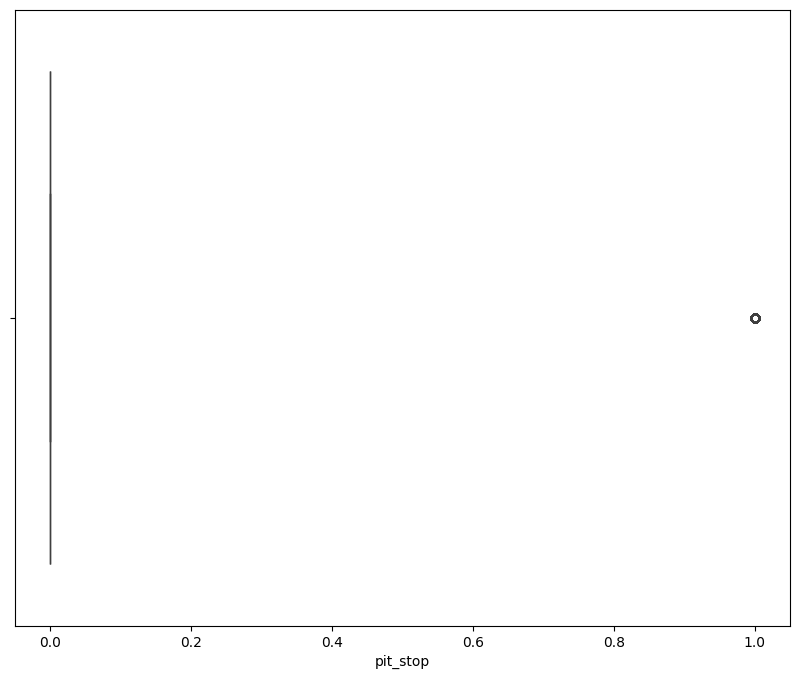

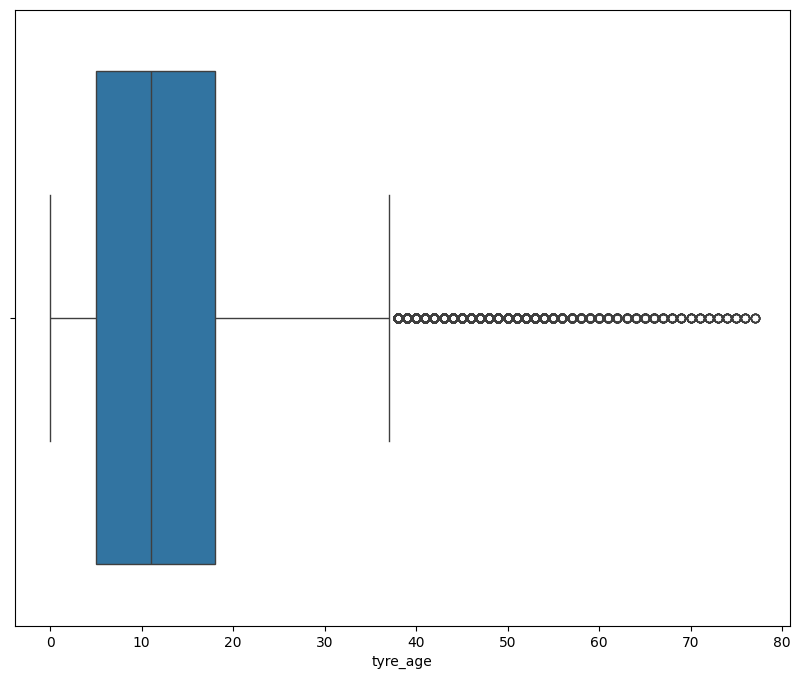

In [28]:
for col in numerical_cols:
    plt.figure(figsize=(10, 8))
    sns.boxplot( x = df[col])

In [29]:
df = df[df['lap_time_ms'] <= 120000]

<Axes: xlabel='lap_time_ms'>

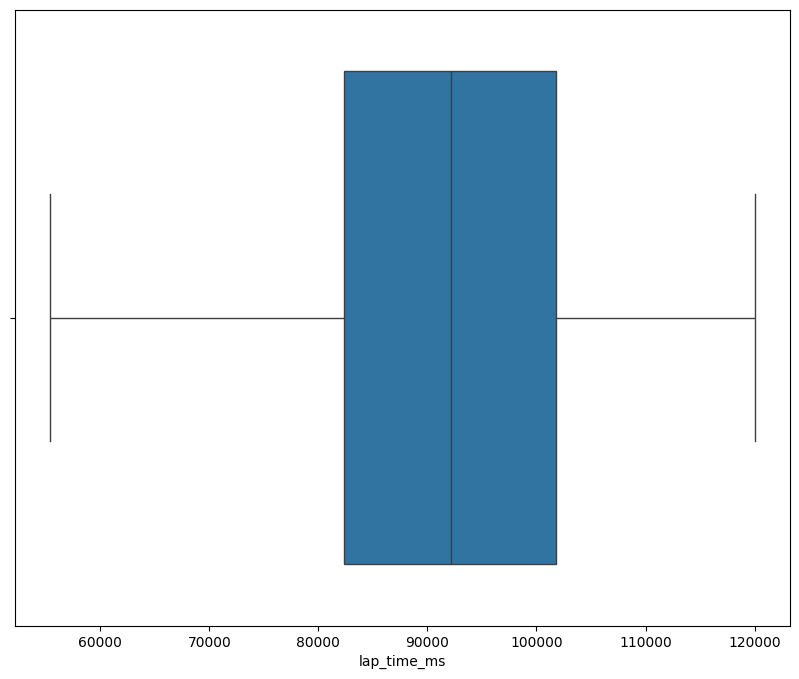

In [30]:

plt.figure(figsize=(10, 8))
sns.boxplot( x = df['lap_time_ms'])

<Axes: >

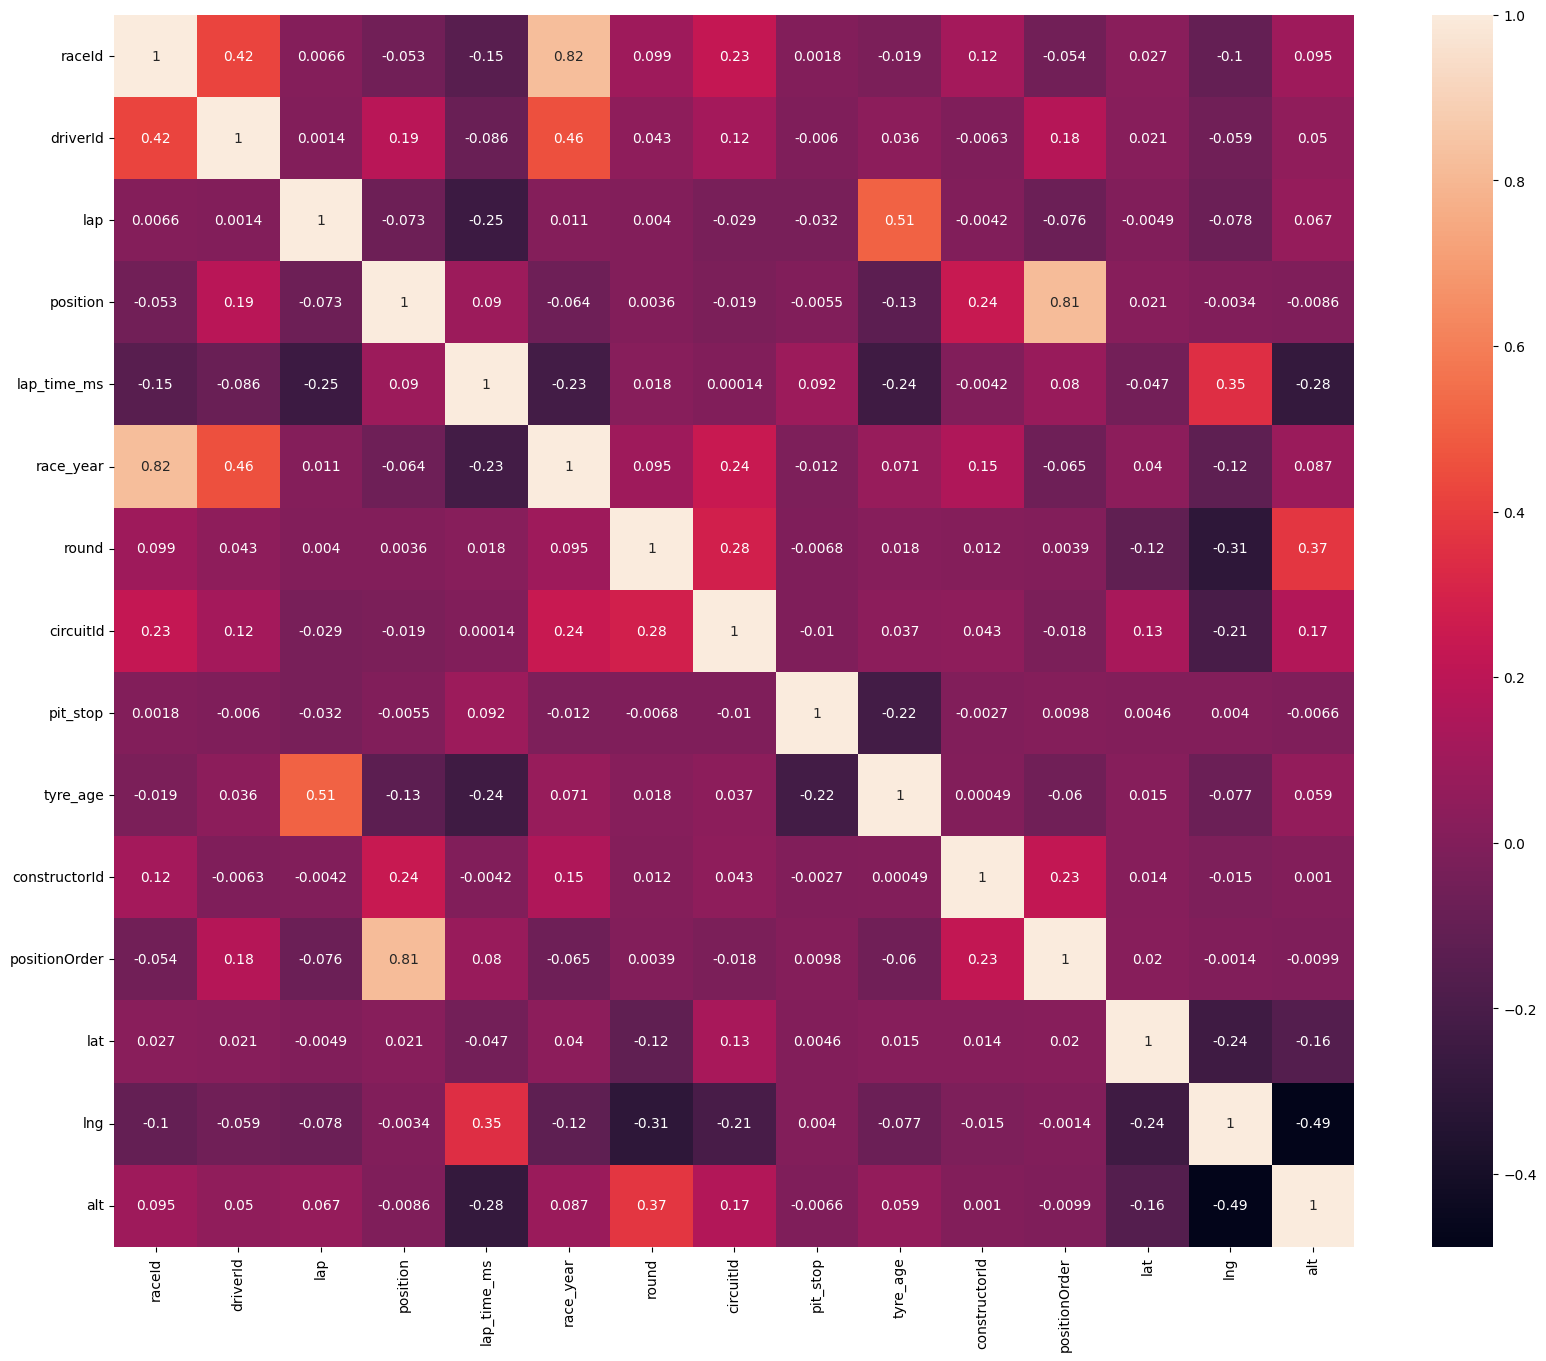

In [31]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [32]:
df.shape

(348196, 19)

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.shape

(348196, 19)

# FEATURE ENG AND EXT

In [35]:
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df = df.dropna(subset=['grid'])

In [36]:
train_df = df[df['race_year'] < 2020]
test_df  = df[df['race_year'] >= 2020]

driver_avg = train_df.groupby('driverId')['lap_time_ms'].mean()

train_df['driver_skill'] = train_df['driverId'].map(driver_avg)
test_df['driver_skill']  = test_df['driverId'].map(driver_avg)

test_df['driver_skill'] = test_df['driver_skill'].fillna(driver_avg.mean())

In [37]:
circuit_avg = train_df.groupby('circuitId')['lap_time_ms'].mean()

train_df['circuit_difficulty'] = train_df['circuitId'].map(circuit_avg)
test_df['circuit_difficulty']  = test_df['circuitId'].map(circuit_avg)

test_df['circuit_difficulty'] = test_df['circuit_difficulty'].fillna(circuit_avg.mean())
df

,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,race_name,race_date,race_time,pit_stop,tyre_age,constructorId,grid,positionOrder,lat,lng,alt
32,337,1,33,4,119706,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,18,1,4.0,3,26.0325,50.5106,7
35,337,1,36,4,119904,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,21,1,4.0,3,26.0325,50.5106,7
40,337,1,41,3,119731,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,26,1,4.0,3,26.0325,50.5106,7
41,337,1,42,3,119560,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,27,1,4.0,3,26.0325,50.5106,7
42,337,1,43,3,119590,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,0,28,1,4.0,3,26.0325,50.5106,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372488,1171,866,49,14,95229,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,31,215,10.0,14,34.8431,136.5410,45
372489,1171,866,50,14,94845,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,32,215,10.0,14,34.8431,136.5410,45
372490,1171,866,51,14,94600,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,33,215,10.0,14,34.8431,136.5410,45
372491,1171,866,52,14,94585,2026,3,22,Japanese Grand Prix,2026-03-29,05:00:00,0,34,215,10.0,14,34.8431,136.5410,45


In [38]:
train_df['prev_lap_time'] = train_df.groupby(['raceId','driverId'])['lap_time_ms'].shift(1)
test_df['prev_lap_time']  = test_df.groupby(['raceId','driverId'])['lap_time_ms'].shift(1)

train_df = train_df.dropna()
test_df  = test_df.dropna()

In [39]:
df.columns

Index(['raceId', 'driverId', 'lap', 'position', 'lap_time_ms', 'race_year',
       'round', 'circuitId', 'race_name', 'race_date', 'race_time', 'pit_stop',
       'tyre_age', 'constructorId', 'grid', 'positionOrder', 'lat', 'lng',
       'alt'],
      dtype='str')

In [40]:
drop_cols = [
    'race_name', 'race_date', 'race_time', 'raceId', 'drverId', 'circuitId', 'constructorId'
]

In [41]:
features = [
    'lap',
    'position',
    'pit_stop',
    'tyre_age',
    'grid',
    'alt',
    'driver_skill',
    'circuit_difficulty',
    'race_year',
    'round',
    'prev_lap_time'
]

In [42]:
df.info()


<class 'pandas.DataFrame'>
Index: 347191 entries, 32 to 372492
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   raceId         347191 non-null  int64  
 1   driverId       347191 non-null  int64  
 2   lap            347191 non-null  int64  
 3   position       347191 non-null  int64  
 4   lap_time_ms    347191 non-null  int64  
 5   race_year      347191 non-null  int64  
 6   round          347191 non-null  int64  
 7   circuitId      347191 non-null  int64  
 8   race_name      347191 non-null  str    
 9   race_date      347191 non-null  str    
 10  race_time      347191 non-null  str    
 11  pit_stop       347191 non-null  int64  
 12  tyre_age       347191 non-null  int64  
 13  constructorId  347191 non-null  int64  
 14  grid           347191 non-null  float64
 15  positionOrder  347191 non-null  int64  
 16  lat            347191 non-null  float64
 17  lng            347191 non-null  float64
 18 

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train = train_df[features]
y_train = train_df['lap_time_ms']

X_test = test_df[features]
y_test = test_df['lap_time_ms']

model = RandomForestRegressor(n_estimators=100, n_jobs=-1)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE (sec):", mean_absolute_error(y_test, y_pred)/1000)

R2: 0.8645025453251
MAE (sec): 2.0676504522034813


In [45]:
joblib.dump(model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [46]:
X_train

,lap,position,pit_stop,tyre_age,grid,alt,driver_skill,circuit_difficulty,race_year,round,prev_lap_time
35,36,4,0,21,4.0,7,92836.562279,100465.742940,2010,1,119706.0
40,41,3,0,26,4.0,7,92836.562279,100465.742940,2010,1,119904.0
41,42,3,0,27,4.0,7,92836.562279,100465.742940,2010,1,119731.0
42,43,3,0,28,4.0,7,92836.562279,100465.742940,2010,1,119560.0
132,35,1,0,19,3.0,7,94610.843135,100465.742940,2010,1,119583.0
...,...,...,...,...,...,...,...,...,...,...,...
226226,51,5,0,38,5.0,3,91267.441004,106968.052669,2019,21,102496.0
226227,52,5,0,39,5.0,3,91267.441004,106968.052669,2019,21,102376.0
226228,53,6,0,40,5.0,3,91267.441004,106968.052669,2019,21,102462.0
226229,54,6,0,41,5.0,3,91267.441004,106968.052669,2019,21,104788.0


In [47]:
y_pred

array([71589.4 , 72059.68, 70381.75, ..., 96025.66, 95207.21, 95354.12],
      shape=(134696,))

# KNN

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [49]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

knn = KNeighborsRegressor(
    n_neighbors=40,  
    n_jobs=-1
)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",40
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [50]:
y_pred_knn = knn.predict(X_test_scaled)

r2_knn  = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)/1000  

print("knn R2:", r2_knn)
print("knn MAE (sec):", mae_knn)

knn R2: 0.7173532229254715
knn MAE (sec): 3.943389814285502


# LINEAR REGG

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred_lr = lr.predict(X_test_scaled)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)/1000  

print("linear regression R2:", r2_lr)
print("linear regression mae (sec):", mae_lr)

linear regression R2: 0.7977657794689864
linear regression mae (sec): 2.9740057732658176
